# Clasificación: 7 modelos x 4 balanceos x 4 optimizadores

Este capítulo entrena y evalúa las **112 combinaciones** de clasificación de la Sección 2 de
la guía sobre el conjunto completo de desarrollo (entrenamiento + validación de la línea base:
246,008 solicitudes). La variable objetivo es `TARGET` (1 = dificultades de pago) y la métrica
de todo el proyecto es el **AUC-ROC**.

El capítulo solo *ejecuta y registra*. El análisis de los optimizadores está en el capítulo 04,
la evaluación detallada de los modelos en el 06 y las pruebas estadísticas en el 09. Todos leen
los resultados desde disco, de modo que no necesitan que este notebook siga abierto.

## 1. Diseño experimental

### Validación cruzada anidada (Sección 3.2)

| Nivel | Pliegues | Para qué se usa |
|---|---|---|
| Externo | 5, estratificados | Solo estimar el desempeño de generalización del procedimiento completo |
| Interno | 3, estratificados, dentro del entrenamiento de cada externo | Correr el optimizador (Grid, Random, Bayesiano o Genético) |

El AUC que se reporta en todo el libro es el del **bucle externo**: el modelo con los
hiperparámetros elegidos en el bucle interno se reajusta sobre todo el entrenamiento del externo
(~197 mil filas) y se evalúa en su validación (~49 mil filas), que nunca participó en la búsqueda.
Reportar el mejor AUC interno sería reportar el máximo de 20 evaluaciones ruidosas: una estimación
sesgada al alza (sesgo de selección). La diferencia entre ambos se mide en el capítulo 04.

**Por qué 5 x 3 y no 10 x 5.** Con 8 % de positivos, cada validación externa tiene unos 3,970
incumplidores y cada validación interna unos 5,300 (sobre ~66 mil filas). El error estándar de un
AUC cercano a 0.76 con esos tamaños es del orden de 0.004-0.005, suficiente para ordenar
configuraciones. Más pliegues reducirían poco esa varianza y multiplicarían un coste que ya es el
cuello de botella del proyecto (ver la estimación de tiempos más abajo).

### Presupuesto igual para los cuatro optimizadores

Cada optimizador dispone de `N_EVALUACIONES = 20` evaluaciones distintas por pliegue externo; cada
evaluación ajusta el modelo en los 3 pliegues internos. Comparar métodos con presupuestos distintos
no diría nada sobre su eficiencia. Grid Search puede usar menos de 20 si su rejilla completa es más
pequeña (limitación estructural del método que se discute en el capítulo 04).

### Umbral de decisión

El AUC no depende del umbral, pero precision, recall y F1 sí. En cada unidad se elige el umbral que
minimiza el coste `10 x FN + FP` (el mismo criterio de la línea base) usando las predicciones
**internas** fuera de muestra de la mejor configuración, y se aplica después a la validación externa.

### Sin fuga de información

* Imputación, escalado y codificación se ajustan solo con el entrenamiento de cada partición
  (externa o interna) y se guardan en cache: no dependen de los hiperparámetros, de modo que
  reutilizarlos es idéntico a reajustarlos en cada evaluación (verificado en el capítulo 04).
* SMOTE y ADASYN se aplican solo al entrenamiento de cada partición, después del preprocesamiento.
  La validación conserva siempre la distribución real.
* La parada temprana de XGBoost usa un 10 % del entrenamiento real, nunca la validación.
* La prueba final (20 %) no se toca en este capítulo.

### Robustez de la ejecución

El estudio se divide en 560 **unidades** (modelo x balanceo x optimizador x pliegue externo). Cada
unidad se guarda en `resultados/corridas/` apenas termina. En consecuencia:

* **Se puede interrumpir en cualquier momento** (botón de detener del kernel, apagar el equipo).
  Al volver a ejecutar la celda, las unidades hechas se saltan y se continúa donde quedó.
* **Un error no detiene el estudio**: la unidad fallida se registra en `resultados/errores.csv`
  (traza completa en `resultados/errores/`) y se pasa a la siguiente. Al volver a ejecutar la celda se
  reintenta automáticamente.
* Cada modelo tiene su propia celda: se pueden correr en el orden que se quiera, en sesiones
  distintas.

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
from src import datos, preprocesamiento as prep, experimento as ex, espacios, balanceo

conj = datos.cargar_traspaso()
display(conj.describir())
print(f"Traspaso generado el {conj.meta['fecha']} con semilla {conj.meta['semilla']}")

,Particion,Filas,Positivos,Mora_%,Columnas,Cuantitativas,Cualitativas
0,desarrollo,246008,19860,8.07,483,467,16
1,prueba,61503,4965,8.07,483,467,16


Traspaso generado el 2026-10-01 21:17 con semilla 42


## 2. Particiones de la validación anidada

Se construyen una sola vez (5 externas + 15 internas, cada una con su preprocesador) y se guardan en
`cache/particiones/` como matrices `float32`. Ocupan del orden de 10 GB. Si los datos o el esquema
de pliegues cambian, la huella del manifiesto lo detecta y la cache se reconstruye sola.

In [3]:
prep.preparar_particiones(conj)
del conj          # a partir de aqui todo se lee de la cache mapeada en memoria
import gc; gc.collect();

## 3. Espacios de búsqueda

Un solo espacio por modelo alimenta a los cuatro optimizadores (la rejilla, el muestreo aleatorio,
el TPE de Optuna y el decodificador del genoma del genético), de modo que todos buscan en la misma
región. Criterios:

* **Escala logarítmica** para los parámetros de regularización y tasa de aprendizaje (`C`, `alpha`,
  `var_smoothing`, `learning_rate`, `reg_lambda`, `reg_alpha`, `gamma`): su efecto es multiplicativo;
  en escala lineal el 90 % de las muestras caería en la década superior del rango.
* **Rangos anclados en la evidencia previa.** La rejilla de la línea base encontró su óptimo en el
  borde (`C = 0.01` con L1) y avisaba que había que ampliar el rango: aquí `C` recorre de 1e-4 a 10.
* **Restricciones por el tamaño muestral y el desbalance.** Con 8 % de positivos, una hoja de 10
  observaciones estima la probabilidad con 0 o 1 incumplidor: `min_samples_leaf` parte de 10 (árbol)
  y de 20 (bosque).
* **Random Forest acotado por su costo marginal.** El AUC de un bosque se estabiliza pasados
  ~200-300 árboles (Probst y Boulesteix, 2018): `n_estimators` va de 100 a 300. Con hojas de al
  menos 20 casos y ~80 mil filas por árbol, cada árbol tiene a lo sumo ~4 mil hojas, que se
  alcanzan con 12-16 niveles: `max_depth` va de 6 a 16. `max_samples` va de 0.3 a 0.7 (≈0.63 es la
  fracción de filas únicas del bootstrap clásico; por encima de 0.7 los árboles pierden diversidad).
  La medición de tiempos mostró que ampliar estos rangos casi duplicaba el costo del estudio sin
  explorar configuraciones distintas en la práctica.
* **KNN:** `k` entre 5 y 300 (log); un `k` menor da puntajes con muy pocos valores distintos. El PCA
  previo (10-80 componentes) atiende la pérdida de contraste de la distancia euclídea en ~600
  dimensiones.
* **SVM:** `gamma` se centra en `1/p ~ 1.6e-3`, la escala natural para ~600 columnas estandarizadas,
  y solo está activo con el núcleo RBF aproximado.

In [4]:
tabla = espacios.tabla_espacios()
display(tabla[tabla["Tarea"] == "clasificacion"].drop(columns="Tarea"))

,Modelo,Hiperparametro,Rango,Escala,Activo si
0,knn,n_vecinos,"[5, 300]",log,siempre
1,knn,ponderacion,"uniform, distance",categorica,siempre
2,knn,n_componentes,"[10, 80]",lineal,siempre
3,naive_bayes,var_smoothing,"[1e-12, 0.1]",log,siempre
4,logistica,C,"[0.0001, 10]",log,siempre
5,logistica,penalizacion,"l1, l2",categorica,siempre
6,arbol,max_depth,"[3, 20]",lineal,siempre
7,arbol,min_samples_leaf,"[10, 2000]",log,siempre
8,arbol,max_features,"sqrt, 0.3, 1.0",categorica,siempre
9,random_forest,n_estimators,"[100, 300]",lineal,siempre


## 4. Balanceo de clases

| Técnica | Qué hace | Implementación |
|---|---|---|
| Sin balanceo | Línea base: el modelo ve el 8 % real de positivos | - |
| SMOTE | Interpola positivos sinteticos entre vecinos de la clase minoritaria | `imblearn`, `k=5`, positivos hasta 1/2 de los negativos |
| ADASYN | Como SMOTE, pero genera mas sinteticos alrededor de los positivos rodeados de negativos (densidad adaptativa) | `imblearn`, `k=5`, misma proporción |
| `class_weight` | No cambia los datos; pondera la perdida por la frecuencia inversa de cada clase | propia de cada modelo (tabla siguiente) |

**Proporción 1:2 y no 1:1.** Llevar la minoritaria a 1:1 generaria unas 165 mil filas sintéticas por
partición a partir de ~16 mil positivos reales: cada caso real se replicaría interpolado unas diez
veces, lo que favorece el sobreajuste a vecindarios particulares y duplica el coste de entrenamiento.
Con 1:2 el entrenamiento pasa de 8 % a 33 % de positivos.

**`class_weight` por modelo.** Dos casos merecen una nota teórica que el capítulo 06 contrasta con
los datos. En **Naive Bayes**, ponderar por clase solo cambia el logaritmo del prior de cada clase
(las medias y varianzas condicionales no cambian), es decir, suma una constante al log-odds: el
ordenamiento, y por tanto el AUC, queda idéntico. En **KNN** multiplicar los votos por un peso
constante por clase produce un puntaje que es función monótona del original: el AUC tampoco cambia.
En ambos casos la técnica solo mueve el umbral. Se ejecutan igual, para que el diseño sea completo y
la predicción teórica quede verificada empíricamente.

In [5]:
pd.DataFrame([(m, n, d) for m, n, d in [('knn', 'K-Nearest Neighbors', 'PCA ajustado solo con el entrenamiento de cada partición + búsqueda exacta de vecinos en la GPU (PyTorch; sin GPU, FAISS en CPU: mismos vecinos). `class_weight` se implementa ponderando el voto de cada vecino por el peso de su clase.'), ('naive_bayes', 'Naive Bayes gaussiano', '`class_weight` entra como `sample_weight` (GaussianNB no tiene el parámetro).'), ('logistica', 'Regresión logística L1/L2', 'L2 con `lbfgs`, L1 con `saga`. Es el modelo de la línea base: aquí se somete al mismo protocolo que los demás.'), ('arbol', 'Árbol de decisión (CART)', "`class_weight='balanced'` nativo."), ('random_forest', 'Random Forest', 'Modo bosque aleatorio de XGBoost en la GPU (`XGBRFClassifier`): árboles independientes, cada uno con una fracción de filas (`max_samples` → `subsample`) y de columnas por nodo (`max_features` → `colsample_bynode`), promediados. La medición de tiempos mostró que el `RandomForestClassifier` de scikit-learn en CPU se llevaba el 72 % del tiempo total del estudio; el capítulo 05 compara ambas implementaciones. `class_weight` = `scale_pos_weight`.'), ('xgboost', 'XGBoost', "`tree_method='hist'`, parada temprana con 10 % del entrenamiento real, GPU si existe. `class_weight` = `scale_pos_weight` (negativos/positivos)."), ('svm', 'SVM', "`LinearSVC` o Nystroem (RBF aproximado) + `LinearSVC`; no produce probabilidades, su puntaje es `decision_function`. `class_weight='balanced'` nativo.")]],
             columns=["clave", "modelo", "implementacion escalable / class_weight"])

,clave,modelo,implementacion escalable / class_weight
0,knn,K-Nearest Neighbors,PCA ajustado solo con el entrenamiento de cada...
1,naive_bayes,Naive Bayes gaussiano,`class_weight` entra como `sample_weight` (Gau...
2,logistica,Regresión logística L1/L2,"L2 con `lbfgs`, L1 con `saga`. Es el modelo de..."
3,arbol,Árbol de decisión (CART),`class_weight='balanced'` nativo.
4,random_forest,Random Forest,Modo bosque aleatorio de XGBoost en la GPU (`X...
5,xgboost,XGBoost,"`tree_method='hist'`, parada temprana con 10 %..."
6,svm,SVM,`LinearSVC` o Nystroem (RBF aproximado) + `Lin...


## 5. Estimación del tiempo antes de lanzar el estudio (opcional)

Mide **una** evaluación real por (modelo, balanceo) en la partición interna `e0/i0`, con la
configuración central de cada espacio, y proyecta el tiempo total con el presupuesto vigente. Tarda
del orden de una hora. Sirve para decidir si conviene ajustar `N_INTERNOS` o `N_EVALUACIONES`
(variables de entorno `E3_N_INTERNOS`, `E3_N_EVALUACIONES`) **antes** de empezar; cambiarlos a mitad
del estudio mezclaría unidades con presupuestos distintos.

Antes de lanzar el estudio, esta estimación proyectó 87.8 horas de cómputo; el estudio consumió 444.5.
El anexo A compara ambas cifras modelo por modelo y explica la diferencia: la configuración central
que se midió era justamente la rápida en la logística (L2), SVM y SVR (núcleo de Nystroem), y la
estimación se hizo con el equipo libre, mientras que el estudio corrió con varias ventanas a la vez.

In [6]:
ESTIMAR_TIEMPOS = False     # cambie a True para medir antes de lanzar
if ESTIMAR_TIEMPOS:
    estimacion = ex.estimar_tiempos("clasificacion")
    display(estimacion)
    estimacion.to_csv(config.DIR_RESULTADOS / "estimacion_tiempos_clasificacion.csv", index=False)

## 6. Ejecución por modelo

Cada celda ejecuta las 80 unidades de un modelo (4 balanceos x 5 pliegues x 4 optimizadores). El
orden interno es balanceo -> pliegue -> optimizador, para que SMOTE/ADASYN se calculen una sola vez
por partición y los reutilicen los cuatro optimizadores.

**Ejecución fuera de Jupyter, en paralelo.** El estudio completo se ejecutó con `correr_estudio.py`,
lanzado desde varios archivos `.bat` a la vez: una ventana para los modelos que usan la GPU (Random
Forest y XGBoost), varias para los de CPU (logística, Naive Bayes, árbol, SVM y los regresores
lineales y SVR) y una para KNN con FAISS. Un bloqueo por unidad impide que dos ventanas ejecuten la
misma. Todas escriben en el mismo registro que estas celdas, de modo que aquí cada celda solo
encuentra sus unidades hechas y las reporta; si faltara alguna, la ejecuta. No cambia nada del
diseño: es el mismo estudio en otro orden. El anexo A documenta esa ejecución, sus fallos y cómo se
repararon.

Estado actual del estudio:

In [7]:
ex.avance("clasificacion")

,tarea,modelo,hechas,totales,con_error
0,clasificacion,knn,80,80,0
1,clasificacion,naive_bayes,80,80,0
2,clasificacion,logistica,80,80,0
3,clasificacion,arbol,80,80,0
4,clasificacion,random_forest,80,80,0
5,clasificacion,xgboost,80,80,0
6,clasificacion,svm,80,80,0


### K-Nearest Neighbors (`knn`)

PCA ajustado solo con el entrenamiento de cada partición + búsqueda exacta de vecinos con FAISS en la CPU (las mismas que daría la búsqueda exacta en la GPU con PyTorch, que se usó en las primeras unidades de regresión; el motor queda registrado en cada unidad, anexo A). `class_weight` se implementa ponderando el voto de cada vecino por el peso de su clase.

In [8]:
estado_knn = ex.ejecutar("clasificacion", modelos=["knn"])

80 unidades | ya hechas: 80 | pendientes: 0

Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### Naive Bayes gaussiano (`naive_bayes`)

`class_weight` entra como `sample_weight` (GaussianNB no tiene el parámetro).

In [9]:
estado_naive_bayes = ex.ejecutar("clasificacion", modelos=["naive_bayes"])

80 unidades | ya hechas: 80 | pendientes: 0



Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### Regresión logística L1/L2 (`logistica`)

L2 con `lbfgs`, L1 con `saga`. Es el modelo de la línea base: aquí se somete al mismo protocolo que los demás.

In [10]:
estado_logistica = ex.ejecutar("clasificacion", modelos=["logistica"])

80 unidades | ya hechas: 80 | pendientes: 0



Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### Árbol de decisión (CART) (`arbol`)

`class_weight='balanced'` nativo.

In [11]:
estado_arbol = ex.ejecutar("clasificacion", modelos=["arbol"])

80 unidades | ya hechas: 80 | pendientes: 0

Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### Random Forest (`random_forest`)

Modo bosque aleatorio de XGBoost en la GPU (`XGBRFClassifier`): árboles independientes, cada uno con una fracción de filas (`max_samples` → `subsample`) y de columnas por nodo (`max_features` → `colsample_bynode`), promediados. La medición de tiempos mostró que el `RandomForestClassifier` de scikit-learn en CPU se habría llevado el 72 % del tiempo total estimado del estudio; el capítulo 05 compara ambas implementaciones. `class_weight` = `scale_pos_weight`.

In [12]:
estado_random_forest = ex.ejecutar("clasificacion", modelos=["random_forest"])

80 unidades | ya hechas: 80 | pendientes: 0



Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### XGBoost (`xgboost`)

`tree_method='hist'`, parada temprana con 10 % del entrenamiento real, GPU si existe. `class_weight` = `scale_pos_weight` (negativos/positivos).

In [13]:
estado_xgboost = ex.ejecutar("clasificacion", modelos=["xgboost"])

80 unidades | ya hechas: 80 | pendientes: 0



Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


### SVM (`svm`)

`LinearSVC` o Nystroem (RBF aproximado) + `LinearSVC`; no produce probabilidades, su puntaje es `decision_function`. `class_weight='balanced'` nativo.

In [14]:
estado_svm = ex.ejecutar("clasificacion", modelos=["svm"])

80 unidades | ya hechas: 80 | pendientes: 0



Resumen: {'hecha': 80} | tiempo de esta ejecucion: 0.00 h


## 7. Verificación del estudio

Unidades completas por modelo y errores registrados. Si hay errores, basta volver a ejecutar la
celda del modelo: solo se reintentan las unidades que faltan. La traza de cada fallo esta en
`resultados/errores/<clave>.txt`.

In [15]:
display(ex.avance("clasificacion"))
ruta_err = config.DIR_RESULTADOS / "errores.csv"
if ruta_err.is_file():
    err = pd.read_csv(ruta_err)
    err = err[err["clave"].str.startswith("clasificacion")]
    pendientes = [c for c in err["clave"].unique()
                  if not (config.DIR_CORRIDAS / f"{c}.json").is_file()]
    print(f"Errores historicos: {len(err)} | aun sin resolver: {len(pendientes)}")
    display(err.tail(10))
else:
    print("Sin errores registrados")

,tarea,modelo,hechas,totales,con_error
0,clasificacion,knn,80,80,0
1,clasificacion,naive_bayes,80,80,0
2,clasificacion,logistica,80,80,0
3,clasificacion,arbol,80,80,0
4,clasificacion,random_forest,80,80,0
5,clasificacion,xgboost,80,80,0
6,clasificacion,svm,80,80,0


Sin errores registrados


## 8. Tabla maestra

Una fila por combinación con la media y la desviación estándar de cada métrica a través de los 5
pliegues externos, tiempos, número de evaluaciones, hiperparámetros de cada pliegue y semilla. Se
guarda en `resultados/tabla_maestra.csv` y `.parquet` (Sección 7.3 de la guía).

In [16]:
pliegues, maestra = ex.consolidar()
clf = maestra[maestra["tarea"] == "clasificacion"]
cols = ["modelo", "balanceo", "optimizador", "m_auc_roc_media", "m_auc_roc_sd",
        "m_recall_media", "m_f1_media", "auc_interno_media", "evaluaciones_total", "t_total_h"]
print(f"Combinaciones completas: {(clf['pliegues'] == config.N_EXTERNOS).sum()} de 112")
display(clf[cols].head(20).style.format(precision=4).hide(axis="index"))

Combinaciones completas: 112 de 112


modelo,balanceo,optimizador,m_auc_roc_media,m_auc_roc_sd,m_recall_media,m_f1_media,auc_interno_media,evaluaciones_total,t_total_h
xgboost,ninguno,genetica,0.7721,0.0038,0.6591,0.2863,0.7699,100,2.0927
xgboost,ninguno,rejilla,0.7720,0.0035,0.6736,0.2844,0.7694,80,1.9516
xgboost,ninguno,aleatoria,0.7717,0.0035,0.6765,0.2810,0.7699,100,1.7486
xgboost,smote,bayesiana,0.7713,0.0039,0.6594,0.2850,0.7686,100,4.8862
xgboost,adasyn,aleatoria,0.7712,0.0027,0.6724,0.2832,0.7687,100,3.1607
xgboost,smote,genetica,0.7710,0.0036,0.6633,0.2847,0.7688,100,4.4158
xgboost,ninguno,bayesiana,0.7710,0.0038,0.6633,0.2843,0.7699,100,2.2732
xgboost,class_weight,bayesiana,0.7709,0.0038,0.6781,0.2823,0.7690,100,2.0904
xgboost,class_weight,aleatoria,0.7708,0.0034,0.6725,0.2822,0.7685,100,1.5376
xgboost,smote,aleatoria,0.7708,0.0037,0.6662,0.2833,0.7683,100,3.3627


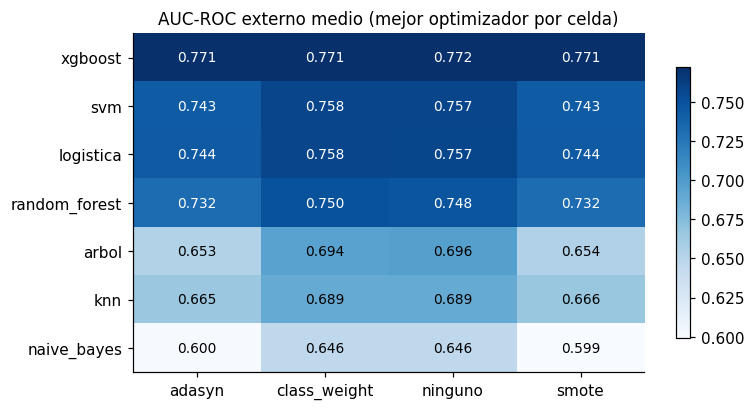

In [17]:
# AUC externo medio por modelo y balanceo (mejor optimizador de cada celda)
tabla = clf.pivot_table(index="modelo", columns="balanceo", values="m_auc_roc_media", aggfunc="max")
tabla = tabla.loc[tabla.max(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7.5, 4))
im = ax.imshow(tabla.to_numpy(), cmap="Blues", aspect="auto")
ax.set_xticks(range(tabla.shape[1]), tabla.columns)
ax.set_yticks(range(tabla.shape[0]), tabla.index)
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        v = tabla.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if v > np.nanmean(tabla.to_numpy()) else "black")
ax.set_title("AUC-ROC externo medio (mejor optimizador por celda)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
graficos.guardar(fig, "02_auc_modelo_balanceo")
plt.show()

**Lectura.** La tabla y el mapa de calor responden las tres preguntas con claridad.

**Qué familia ordena mejor el riesgo.** XGBoost, con holgura: sus 16 combinaciones ocupan los 16
primeros puestos de la tabla maestra (AUC externo medio entre 0.7702 y 0.7721), y la mejor
combinación de otra familia —SVM con `class_weight` y optimizador genético, 0.7578— queda 0.014 por
debajo. Detrás vienen SVM y la logística, prácticamente empatadas (0.758 en su mejor celda), Random
Forest (0.750) y, a distancia, el árbol (0.696), KNN (0.689) y Naive Bayes (0.646). Dentro de XGBoost
la distancia entre la primera y la decimosexta combinación (0.0019) es la mitad de la desviación
entre pliegues (≈ 0.0035): ninguna combinación de balanceo u optimizador destaca dentro de la familia.

**Si el balanceo mueve el AUC.** Sí, y hacia abajo. SMOTE y ADASYN reducen el AUC en todas las
familias salvo XGBoost, con caídas muy superiores a la desviación entre pliegues: unas 0.014 en
logística y SVM, 0.016-0.018 en Random Forest, 0.023 en KNN, 0.042 en el árbol y 0.046-0.047 en Naive Bayes
(mejor celda de cada caso). Una explicación plausible es que los positivos sintéticos se interpolan
en un espacio de ~600 dimensiones con muchas variables imputadas o indicadoras, y los modelos que
dependen de distancias, de densidades o de regiones puras aprenden de ellos fronteras que no existen
en los datos reales. En XGBoost la diferencia es de 0.001, dentro del ruido. El capítulo 06 (sección
5) lo confirma con una prueba pareada.

**Invariancia con `class_weight`.** Se cumple: el mapa muestra exactamente el mismo AUC con y sin
ponderación en Naive Bayes (0.646) y en KNN (0.689). En Naive Bayes ponderar las clases solo cambia
las probabilidades a priori, lo que suma una constante al logit de todas las observaciones; en KNN
multiplica el voto de cada clase por un factor común. Ambas son transformaciones monótonas del
puntaje, y el AUC, que solo depende del orden, no cambia.